In [1]:
import numpy as np
from model_ranking import load_h5, get_roi_slice

In [2]:
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from typing import Any

def plot_example_predictions(
    num_samples: int, 
    patch_indexes: NDArray[Any], 
    seed: int, 
    predictions: NDArray[Any], 
    raw: NDArray[Any]
)->None:
    """
    Plots example images of paired predictions and raw patches.

    Args:
        num_samples (int): Number of samples to show.
        patch_indexes (np.ndarray): Array of shape (N, 3, 2) with ROI slices for each patch.
        seed (int): Random seed for reproducibility.
        predictions (np.ndarray): Array of predicted patches, shape (N, ...).
        raw (np.ndarray): Raw image array to extract patches from.
    """
    np.random.seed(seed)
    idxs = np.random.choice(len(patch_indexes), size=num_samples, replace=False)
    ncols = min(num_samples, 4)
    nrows = int(np.ceil(num_samples / ncols))
    fig, axes = plt.subplots(nrows, ncols * 2, figsize=(4 * ncols, 3 * nrows))

    if nrows == 1:
        axes = np.expand_dims(axes, 0)
    axes = axes.reshape(nrows, ncols * 2)

    for i, idx in enumerate(idxs):
        row = i // ncols
        col = (i % ncols) * 2

        roi = get_roi_slice(patch_indexes[idx])
        

        raw_patch = raw[roi]
        pred_patch = predictions[idx, 0] if predictions.ndim == 5 else predictions[idx]

        # Plot raw patch
        ax_raw = axes[row, col]
        ax_raw.imshow(raw_patch[0] if raw_patch.ndim == 3 else raw_patch, cmap='gray')
        ax_raw.set_title(f'Raw Patch {idx}')
        ax_raw.axis('off')

        # Plot prediction patch
        ax_pred = axes[row, col + 1]
        ax_pred.imshow(pred_patch[0] if pred_patch.ndim == 3 else pred_patch, cmap='magma')
        ax_pred.set_title(f'Prediction {idx}')
        ax_pred.axis('off')

    # Hide unused axes
    for j in range(i + 1, nrows * ncols):
        for k in range(2):
            axes[j // ncols, (j % ncols) * 2 + k].axis('off')

    plt.tight_layout()
    plt.show()

In [3]:
VNC_fullsize_path = "/scratch/talks/data/VNC/data_labeled_mito.h5"
VNC_fullsize = load_h5(VNC_fullsize_path, "raw")

In [4]:
VNC_downsample_path = "/scratch/talks/data/VNC/resized_pixels/source_mitoEM_true.h5"
VNC_downsample = load_h5(VNC_downsample_path, "resized_raw")

In [5]:
HtoV_pred_fullsize_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_VNC_gap/feature_perturbation_consistency/FP_3/Hm_model3/norm_Normalize/none/predictions/data_labeled_mito_none.h5"
HtoV_pred_fullsize = load_h5(HtoV_pred_fullsize_path, "predictions")
HtoV_fullsize_f1 = load_h5(HtoV_pred_fullsize_path, "hard_f1")
V_fullsize_patches = load_h5(HtoV_pred_fullsize_path, "patch_index")

In [6]:
HtoV_pred_downsample_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_VNC_gap/feature_perturbation_consistency/resized/Hm_model3/norm_Normalize/none/predictions/source_mitoEM_true_predictions.h5"
HtoV_pred_downsample = load_h5(HtoV_pred_downsample_path, "predictions")
HtoV_downsample_f1 = load_h5(HtoV_pred_downsample_path, "hard_f1")
V_downsample_patches = load_h5(HtoV_pred_downsample_path, "patch_index")

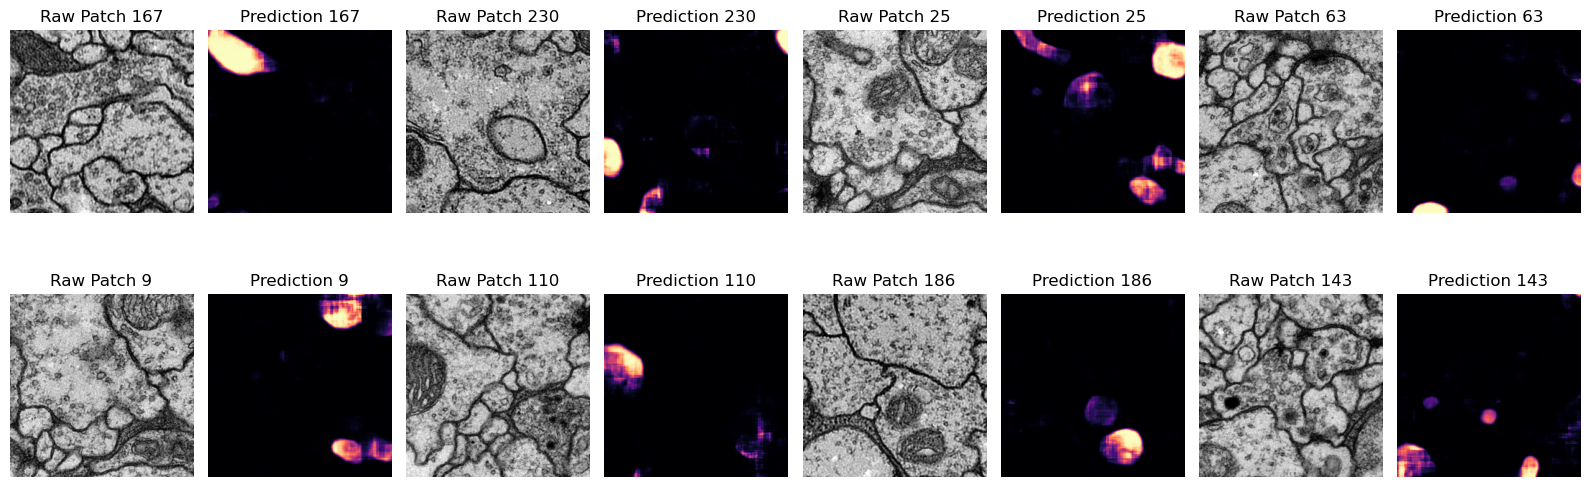

In [7]:
plot_example_predictions(8, V_fullsize_patches, 42, HtoV_pred_fullsize, VNC_fullsize)

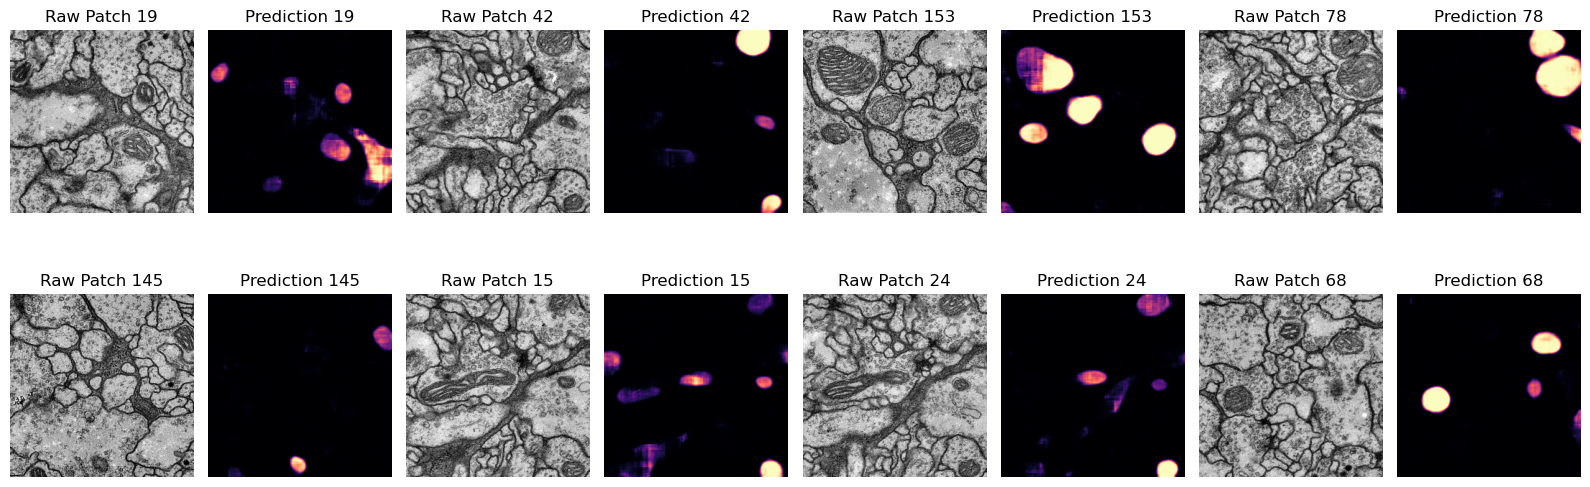

In [8]:
plot_example_predictions(8, V_downsample_patches, 42, HtoV_pred_downsample, VNC_downsample)

In [9]:
print(f"HtoV fullsize F1 score {np.median(HtoV_fullsize_f1, axis=0)}")
print(f"HtoV downsample F1 score {np.median(HtoV_downsample_f1, axis=0)}")

HtoV fullsize F1 score [0.9818164  0.36342016]
HtoV downsample F1 score [0.98396677 0.6358272 ]


In [10]:
RtoV_pred_fullsize_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_VNC_gap/feature_perturbation_consistency/FP_3/Rm_model3/norm_Normalize/none/predictions/data_labeled_mito_none.h5"
RtoV_pred_fullsize = load_h5(RtoV_pred_fullsize_path, "predictions")
RtoV_fullsize_f1 = load_h5(RtoV_pred_fullsize_path, "hard_f1")
V_fullsize_patches = load_h5(RtoV_pred_fullsize_path, "patch_index")

In [11]:
RtoV_pred_downsample_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_VNC_gap/feature_perturbation_consistency/resized/Rm_model3/norm_Normalize/none/predictions/source_mitoEM_true_predictions.h5"
RtoV_pred_downsample = load_h5(RtoV_pred_downsample_path, "predictions")
RtoV_downsample_f1 = load_h5(RtoV_pred_downsample_path, "hard_f1")
V_downsample_patches = load_h5(RtoV_pred_downsample_path, "patch_index")

In [13]:
print("RtoV fullsize F1 score:", np.median(RtoV_fullsize_f1, axis=0))
print("RtoV downsample F1 score:", np.median(RtoV_downsample_f1, axis=0))

RtoV fullsize F1 score: [0.9731997  0.08269954]
RtoV downsample F1 score: [0.9553518  0.16013971]


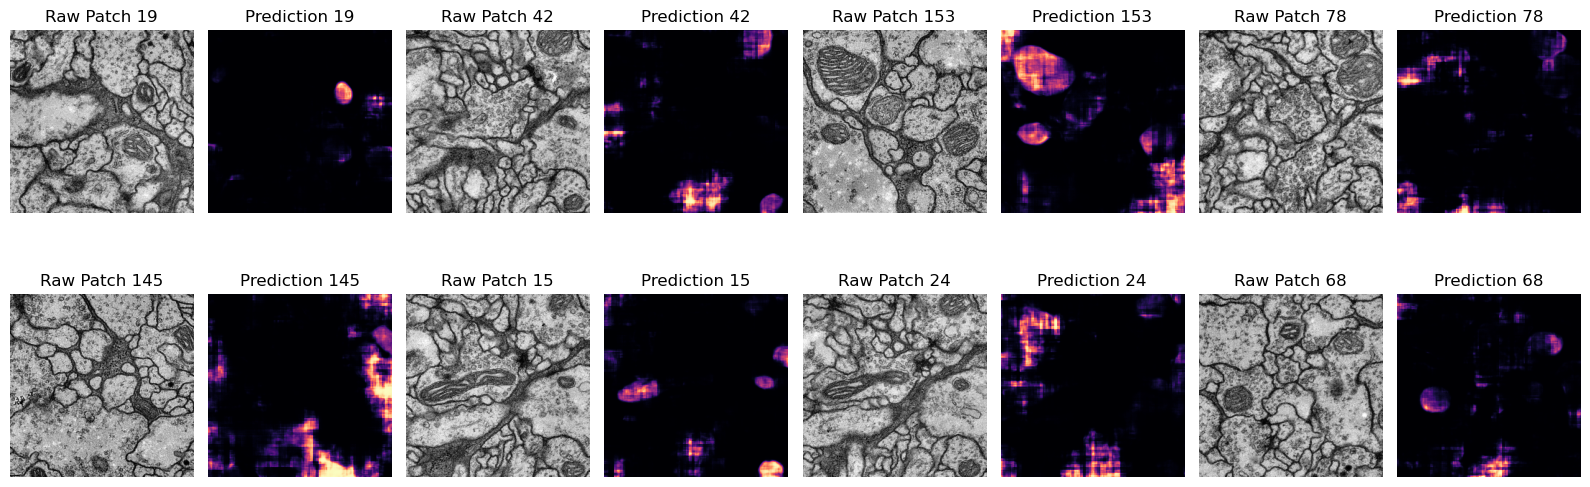

In [14]:
plot_example_predictions(8, V_downsample_patches, 42, RtoV_pred_downsample, VNC_downsample)

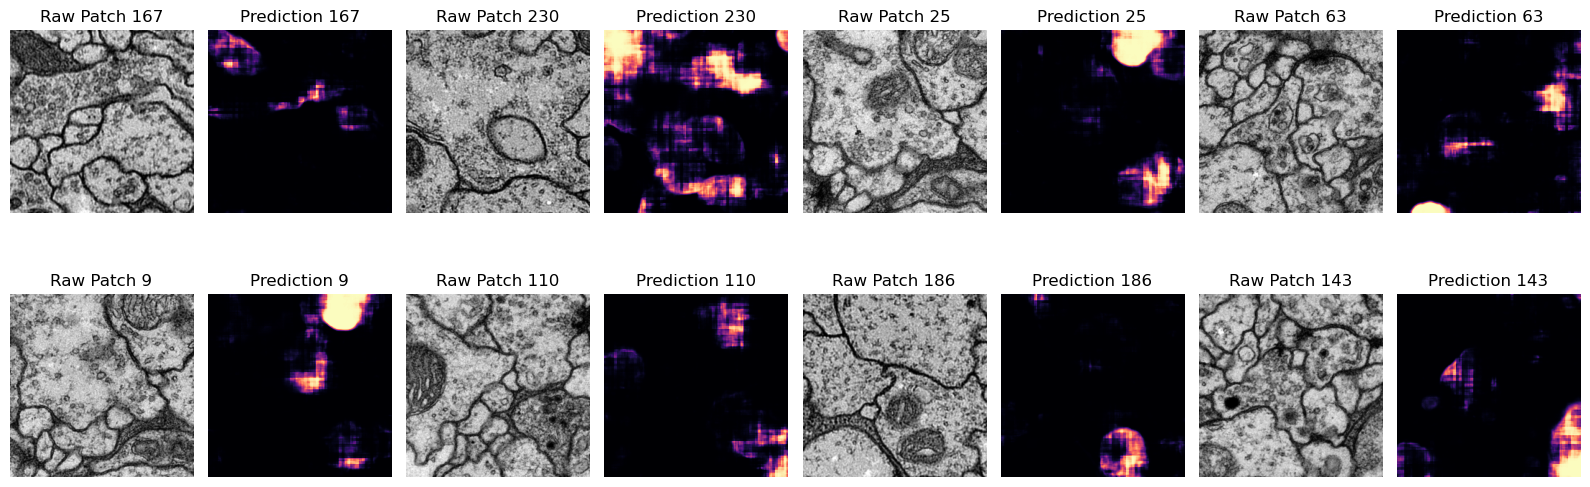

In [15]:
plot_example_predictions(8, V_fullsize_patches, 42, RtoV_pred_fullsize, VNC_fullsize)

In [16]:
EtoV_pred_fullsize_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_VNC_gap/feature_perturbation_consistency/FP_3/E_model4/norm_Normalize/none/predictions/data_labeled_mito_none.h5"
EtoV_pred_fullsize = load_h5(EtoV_pred_fullsize_path, "predictions")
EtoV_fullsize_f1 = load_h5(EtoV_pred_fullsize_path, "hard_f1")
V_fullsize_patches = load_h5(EtoV_pred_fullsize_path, "patch_index")

In [17]:
EtoV_pred_downsample_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_VNC_gap/feature_perturbation_consistency/resized/E_model4/norm_Normalize/none/predictions/source_mitoEM_true_predictions.h5"
EtoV_pred_downsample = load_h5(EtoV_pred_downsample_path, "predictions")
EtoV_downsample_f1 = load_h5(EtoV_pred_downsample_path, "hard_f1")
V_downsample_patches = load_h5(EtoV_pred_downsample_path, "patch_index")

In [18]:
print("EtoV fullsize F1 score:", np.median(EtoV_fullsize_f1, axis=0))
print("EtoV downsample F1 score:", np.median(EtoV_downsample_f1, axis=0))

EtoV fullsize F1 score: [0.9797491 0.       ]
EtoV downsample F1 score: [0.97797513 0.38386324]


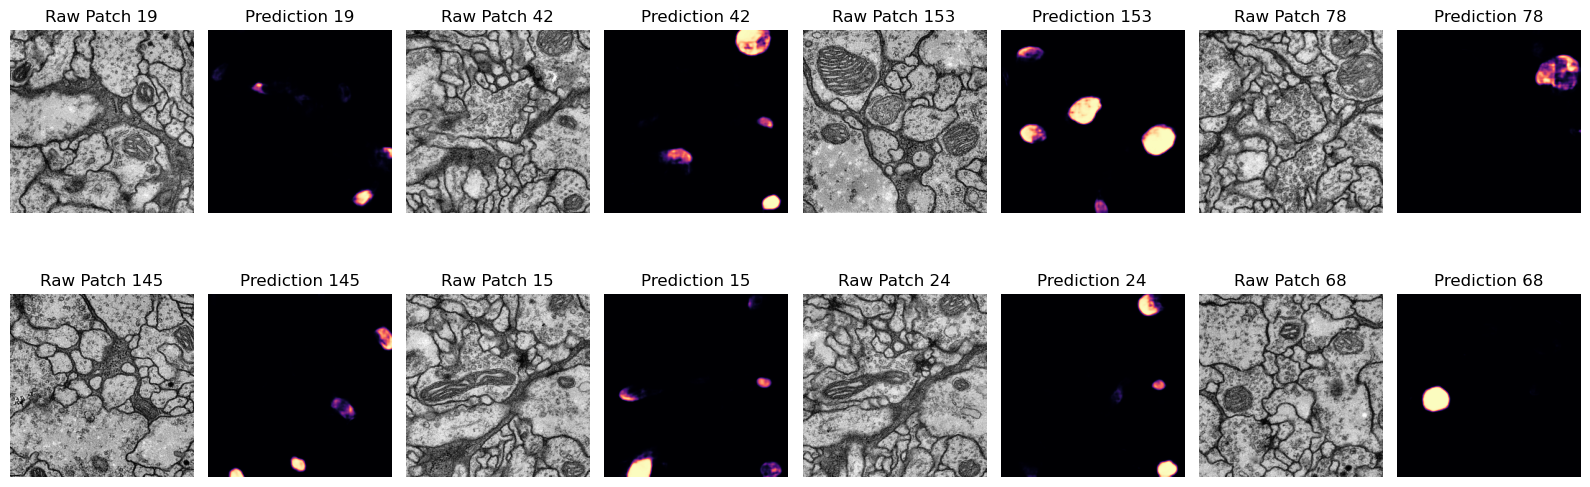

In [31]:
plot_example_predictions(8, V_downsample_patches, 42, EtoV_pred_downsample, VNC_downsample)

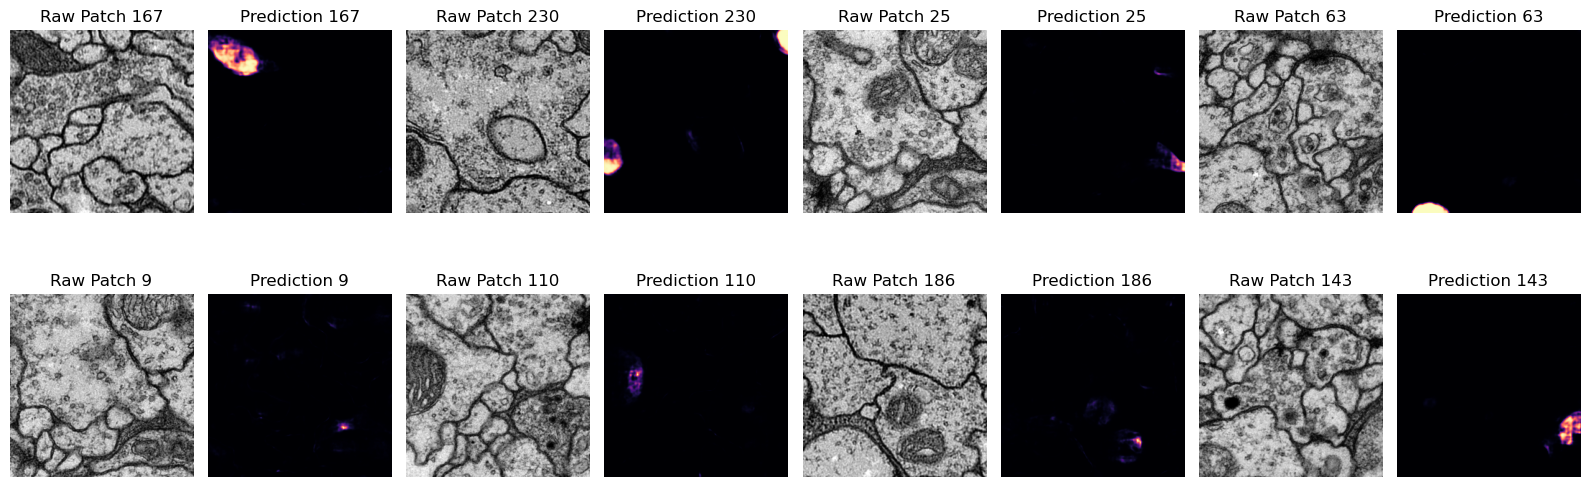

In [32]:
plot_example_predictions(8, V_fullsize_patches, 42, EtoV_pred_fullsize, VNC_fullsize)